In [1]:
pip install  seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df["Customer ID"] = pd.to_numeric(df["Customer ID"], errors="coerce")

In [11]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [13]:
df.rename(columns={
    'InvoiceDate': 'Invoice_Date',
    'Customer ID': 'Customer_ID',
    'StockCode':'Stock_Code'
    }, inplace=True)

In [14]:
df.columns

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country'],
      dtype='str')

In [16]:
df['Customer_ID'].isna().sum()

np.int64(243007)

In [54]:
df[df['Customer_ID'].isna()].sample(5)

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
263422,514835,15036,ASSORTED COLOURS SILK FAN,2,2010-07-06 14:25:00,1.28,NaN,United Kingdom
459524,532953,85132A,CHARLIE + LOLA BISCUITS TINS,3,2010-11-15 12:17:00,8.47,NaN,United Kingdom
271077,515688,22627,MINT KITCHEN SCALES,2,2010-07-14 12:05:00,8.50,NaN,EIRE
50672,494016,90120D,WHITE MURANO TWIST BRACELET,2,2010-01-11 09:35:00,4.33,NaN,United Kingdom
677808,549586,21213,PACK OF 72 SKULL CAKE CASES,4,2011-04-11 10:00:00,2.08,NaN,United Kingdom


In [56]:
online_retail_without_CustID = df[df['Customer_ID'].isna()]

In [59]:
print(online_retail_without_CustID.shape)

(243007, 8)


In [60]:
online_retail_without_CustID.to_csv('online_retail_without_CustID.csv', index=False)

In [61]:
online_retail_with_CustID = df[df['Customer_ID'].notna()]

In [62]:
print(online_retail_with_CustID.shape)

(824364, 8)


In [64]:
online_retail_with_CustID.to_csv('online_retail_with_CustID.csv', index=False)

In [65]:
data = pd.read_csv('online_retail_with_CustID.csv')
data.head()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [66]:
data.isna().sum()

Invoice         0
Stock_Code      0
Description     0
Quantity        0
Invoice_Date    0
Price           0
Customer_ID     0
Country         0
dtype: int64

In [68]:
data_cancelled = data[data['Invoice'].astype(str).str.startswith('C')]
data_cancelled.head()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [71]:
data_cancelled.shape

(18744, 8)

In [69]:
data_valid = data[~data['Invoice'].astype(str).str.startswith('C')]
data_valid.head()


,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [70]:
data_valid.shape

(805620, 8)

In [76]:
data_valid.duplicated().sum()

np.int64(26125)

In [105]:
data_valid[data_valid.duplicated()]

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
387,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
368,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
376,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
359,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
360,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
824094,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
824085,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
824098,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom
824110,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom


In [85]:
data_valid[data_valid['Quantity'] < 0]

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country


In [91]:
data_valid['Invoice_Date'] = pd.to_datetime(data_valid['Invoice_Date'])

In [116]:
data_valid[data_valid.duplicated(
    subset=['Customer_ID','Invoice','Stock_Code','Invoice_Date','Quantity','Price','Description','Country'],
    keep='first'
)]

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
387,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
368,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
376,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
359,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
360,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
824094,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
824085,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
824098,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom
824110,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom


In [96]:
data_valid.shape

(805620, 8)

In [104]:
data_valid=data_valid.sort_values(by=['Invoice_Date'])

In [117]:
data_valid = data_valid.drop_duplicates()

In [119]:
data_valid.shape

(779495, 8)

In [120]:
data_valid.head()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [121]:
data_cancelled.shape

(18744, 8)

In [123]:
data_cancelled.head()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [132]:
data_cancelled[data_cancelled.duplicated(
    subset=['Customer_ID','Invoice','Stock_Code','Invoice_Date','Quantity','Price','Description','Country'],
    keep='first'
)]

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
31298,C493190,22339,CHRISTMAS TREE PAINTED ZINC,-1,2009-12-22 13:08:00,0.65,15581.0,United Kingdom
31322,C493191,72800D,S/4 BLUE DINNER CANDLE SILVER FLOCK,-1,2009-12-22 13:13:00,2.55,15581.0,United Kingdom
76803,C499419,21630,FLOOR CUSHION ELEPHANT CARNIVAL,-1,2010-02-26 16:26:00,8.95,15538.0,United Kingdom
107607,C502899,21733,RED HANGING HEART T-LIGHT HOLDER,-1,2010-03-29 12:03:00,2.95,14680.0,United Kingdom
109208,C503166,21636,MADRAS NOTEBOOK MEDIUM,-12,2010-03-30 13:23:00,2.55,17464.0,United Kingdom
...,...,...,...,...,...,...,...,...
724697,C572226,85066,CREAM SWEETHEART MINI CHEST,-1,2011-10-21 13:58:00,12.75,15321.0,United Kingdom
744823,C574095,22326,ROUND SNACK BOXES SET OF4 WOODLAND,-1,2011-11-03 09:54:00,2.95,12674.0,France
748216,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
764859,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom


In [133]:
data_cancelled = data_cancelled.drop_duplicates()

In [134]:
data_cancelled.shape

(18390, 8)

In [135]:
data_cancelled.duplicated().sum()

np.int64(0)

In [124]:
print(df.shape,"\n")
print(df.head(),"\n")
print(df.tail(),"\n")

(1067371, 8) 

  Invoice Stock_Code                          Description  Quantity  \
0  489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434     79323P                   PINK CHERRY LIGHTS        12   
2  489434     79323W                  WHITE CHERRY LIGHTS        12   
3  489434      22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          Invoice_Date  Price  Customer_ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom   

        Invoice Stock_Code                      Description  Quantity  \
1067366  581587      22899     CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587      23254    CHILDRENS CUTL

In [126]:
print(df.columns,"\n")
print(df.dtypes,"\n")

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country'],
      dtype='str') 

Invoice             str
Stock_Code          str
Description         str
Quantity          int64
Invoice_Date        str
Price           float64
Customer_ID     float64
Country             str
dtype: object 



In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Invoice       1067371 non-null  str    
 1   Stock_Code    1067371 non-null  str    
 2   Description   1062989 non-null  str    
 3   Quantity      1067371 non-null  int64  
 4   Invoice_Date  1067371 non-null  str    
 5   Price         1067371 non-null  float64
 6   Customer_ID   824364 non-null   float64
 7   Country       1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [128]:
df.isnull().sum()

Invoice              0
Stock_Code           0
Description       4382
Quantity             0
Invoice_Date         0
Price                0
Customer_ID     243007
Country              0
dtype: int64

In [129]:
df.duplicated().sum()

np.int64(34335)

In [130]:
df.describe()

,Quantity,Price,Customer_ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [136]:
cleaned_data_with_cancelled = pd.concat([data_valid, data_cancelled], ignore_index=True)

In [148]:
cleaned_data_with_cancelled['Invoice_Date'] = cleaned_data_with_cancelled['Invoice_Date'].astype('datetime64[ns]')

In [151]:
cleaned_data_with_cancelled['Customer_ID'] = cleaned_data_with_cancelled['Customer_ID'].astype('Int64')

In [152]:
cleaned_data_with_cancelled.dtypes

Invoice                    str
Stock_Code                 str
Description                str
Quantity                 int64
Invoice_Date    datetime64[ns]
Price                  float64
Customer_ID              Int64
Country                    str
dtype: object

In [153]:
cleaned_data_with_cancelled.shape

(797885, 8)

In [154]:
cleaned_data_with_cancelled.to_csv("cleaned_data_with_cancelled.csv", index=False)

In [138]:
cleaned_data_without_cancelled = data_valid.copy()

In [155]:
cleaned_data_without_cancelled['Customer_ID'] = cleaned_data_without_cancelled['Customer_ID'].astype('Int64')

In [156]:
cleaned_data_without_cancelled['Invoice_Date'] = cleaned_data_without_cancelled['Invoice_Date'].astype('datetime64[ns]')

In [157]:
cleaned_data_without_cancelled.dtypes

Invoice                    str
Stock_Code                 str
Description                str
Quantity                 int64
Invoice_Date    datetime64[ns]
Price                  float64
Customer_ID              Int64
Country                    str
dtype: object

In [158]:
cleaned_data_without_cancelled.shape

(779495, 8)

In [159]:
cleaned_data_without_cancelled.to_csv("cleaned_data_without_cancelled.csv", index=False)

In [160]:
cleaned_data_with_cancelled.head()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [161]:
cleaned_data_with_cancelled.tail()

,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
797880,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
797881,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
797882,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
797883,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom
797884,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [163]:
cleaned_data_with_cancelled.columns

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country'],
      dtype='str')

In [164]:
cleaned_data_with_cancelled.dtypes

Invoice                    str
Stock_Code                 str
Description                str
Quantity                 int64
Invoice_Date    datetime64[ns]
Price                  float64
Customer_ID              Int64
Country                    str
dtype: object

In [162]:
cleaned_data_with_cancelled.isna().sum()

Invoice         0
Stock_Code      0
Description     0
Quantity        0
Invoice_Date    0
Price           0
Customer_ID     0
Country         0
dtype: int64

In [165]:
cleaned_data_with_cancelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 797885 entries, 0 to 797884
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       797885 non-null  str           
 1   Stock_Code    797885 non-null  str           
 2   Description   797885 non-null  str           
 3   Quantity      797885 non-null  int64         
 4   Invoice_Date  797885 non-null  datetime64[ns]
 5   Price         797885 non-null  float64       
 6   Customer_ID   797885 non-null  Int64         
 7   Country       797885 non-null  str           
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), str(4)
memory usage: 49.5 MB


In [167]:
cleaned_data_with_cancelled.duplicated().sum()

np.int64(0)

In [168]:
cleaned_data_with_cancelled.describe()

,Quantity,Invoice_Date,Price,Customer_ID
count,797885.000000,797885,797885.000000,797885.0
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.0
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.0
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.0
75%,12.000000,2011-07-31 15:50:00,3.750000,16788.0
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0
std,191.670371,NaN,71.392549,1696.466663


In [4]:
import pandas as pd
cleaned_data_with_cancelled = pd.read_csv("online_retail_cleaned_data_with_cancelled.csv")

C:\Users\varun\AppData\Local\Temp\ipykernel_5024\513218860.py:2: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_data_with_cancelled = pd.read_csv("online_retail_cleaned_data_with_cancelled.csv")


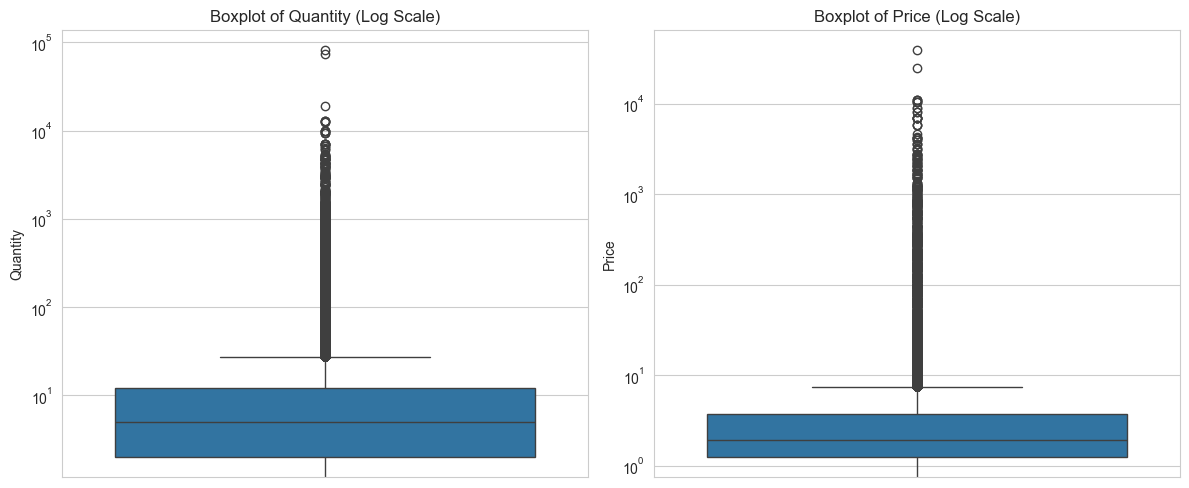

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12,5))

# Quantity
plt.subplot(1,2,1)
sns.boxplot(y=cleaned_data_with_cancelled['Quantity'])
plt.yscale('log')
plt.title("Boxplot of Quantity (Log Scale)")

# Price
plt.subplot(1,2,2)
sns.boxplot(y=cleaned_data_with_cancelled['Price'])
plt.yscale('log')
plt.title("Boxplot of Price (Log Scale)")

plt.tight_layout()
plt.show()

In [11]:
def check_outliers(df, column):

    Q1 = df[column].quantile(0.10)
    Q3 = df[column].quantile(0.90)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column} Outliers:", len(outliers))
    return outliers

In [10]:
check_outliers(cleaned_data_with_cancelled, 'Quantity')


Quantity Outliers: 53167


,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
54,489438,84032B,CHARLIE + LOLA RED HOT WATER BOTTLE,56,2009-12-01 09:24:00,1.90,18102,United Kingdom
55,489438,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,60,2009-12-01 09:24:00,2.40,18102,United Kingdom
56,489438,85183A,CHARLIE & LOLA WASTEPAPER BIN BLUE,60,2009-12-01 09:24:00,2.40,18102,United Kingdom
57,489438,85132C,CHARLIE AND LOLA FIGURES TINS,60,2009-12-01 09:24:00,6.40,18102,United Kingdom
...,...,...,...,...,...,...,...,...
797840,C581330,22959,WRAP CHRISTMAS VILLAGE,-25,2011-12-08 11:57:00,0.42,15877,United Kingdom
797841,C581330,16169E,WRAP 50'S CHRISTMAS,-100,2011-12-08 11:57:00,0.42,15877,United Kingdom
797861,C581462,16219,HOUSE SHAPE PENCIL SHARPENER,-48,2011-12-08 18:51:00,0.06,12985,United Kingdom
797862,C581462,21642,ASSORTED TUTTI FRUTTI PEN,-72,2011-12-08 18:51:00,0.29,12985,United Kingdom


In [53]:
check_outliers(cleaned_data_with_cancelled, 'Price').sample(15)

Price Outliers: 7008


,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
254709,522113,21667,GLASS CAKE COVER AND PLATE,2,2010-09-12 15:38:00,16.95,17021,United Kingdom
98091,502463,84078A,SET/4 WHITE RETRO STORAGE CUBES,1,2010-03-24 14:49:00,39.95,15605,United Kingdom
718194,575632,M,Manual,1,2011-11-10 13:44:00,40.46,12473,Germany
610741,565056,22823,CHEST NATURAL WOOD 20 DRAWERS,2,2011-08-31 17:12:00,110.00,16278,United Kingdom
787788,C529354,M,Manual,-1,2010-10-28 09:43:00,1155.60,14156,EIRE
96950,502280,C2,CARRIAGE,1,2010-03-23 16:45:00,50.00,14156,EIRE
713107,575067,POST,POSTAGE,2,2011-11-08 12:45:00,18.00,12583,France
643771,568472,POST,POSTAGE,2,2011-09-27 11:50:00,18.00,12517,Germany
675222,571441,84707B,PINK JEWELLED MIRROR TRINKET TRAY,1,2011-10-17 13:31:00,19.96,14096,United Kingdom
563765,559513,22846,BREAD BIN DINER STYLE RED,1,2011-07-08 15:56:00,16.95,14534,United Kingdom


In [56]:
cleaned_data_without_cancelled = cleaned_data_with_cancelled[~cleaned_data_with_cancelled['Invoice'].astype(str).str.startswith('C')]

In [58]:
cleaned_data_without_cancelled.dtypes

Invoice          object
Stock_Code          str
Description         str
Quantity          int64
Invoice_Date        str
Price           float64
Customer_ID       int64
Country             str
dtype: object

In [59]:
numeric_cols = cleaned_data_without_cancelled.select_dtypes(include=['int64', 'float64']).columns
cleaned_data_without_cancelled[numeric_cols].corr()

,Quantity,Price,Customer_ID
Quantity,1.000000,-0.004870,-0.008659
Price,-0.004870,1.000000,-0.007497
Customer_ID,-0.008659,-0.007497,1.000000


In [61]:
check_outliers(cleaned_data_without_cancelled, 'Quantity').sample(15)

Quantity Outliers: 22892


,Invoice,Stock_Code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country
478875,548371,21240,BLUE POLKADOT CUP,350,2011-03-30 16:28:00,0.72,17757,United Kingdom
610567,564965,23209,LUNCH BAG VINTAGE DOILY,100,2011-08-31 15:07:00,1.45,17677,United Kingdom
859,489539,21500,PINK SPOTS WRAP,100,2009-12-01 12:18:00,0.34,15061,United Kingdom
137337,507178,22294,HEART FILIGREE DOVE SMALL,288,2010-05-06 15:17:00,1.06,14646,Netherlands
771884,580744,22097,SWALLOW SQUARE TISSUE BOX,216,2011-12-06 09:31:00,0.39,13694,United Kingdom
406820,538945,21231,SWEETHEART CERAMIC TRINKET BOX,72,2010-12-15 11:22:00,1.06,17230,United Kingdom
574579,560729,23297,SET 40 HEART SHAPE PETIT FOUR CASES,144,2011-07-20 14:39:00,1.65,17511,United Kingdom
625493,566595,22952,60 CAKE CASES VINTAGE CHRISTMAS,720,2011-09-13 15:03:00,0.42,18251,United Kingdom
229680,519124,22699,ROSES REGENCY TEACUP AND SAUCER,312,2010-08-13 12:23:00,2.40,17949,United Kingdom
688288,572670,22065,CHRISTMAS PUDDING TRINKET POT,1200,2011-10-25 13:14:00,0.39,13685,United Kingdom


In [ ]:
plt.figure(figsize=(12,5))

for i, col in enumerate(['Quantity', 'Price'], start=1):
    plt.subplot(1, 2, i)
    sns.histplot(cleaned_data_without_cancelled[col], bins=50000, kde=True)
    plt.title(f"Distribution of {col}")
    if col == 'Price':
        plt.xlim(left=0)
    plt.xlabel(col)

plt.tight_layout()
plt.show()